In [1]:
# install the dependencies (pandas, numpy, openpyxl for .xlsx, ...)
%pip install pandas numpy openpyxl matplotlib seaborn scikit-learn -q

# import the dependencies
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Rolling sales by borough: one Excel file per NYC borough under ./data
DATA_DIR = Path("data")

# (display name, filename) — values must be borough labels, not paths alone
BOROUGH_FILES = [
    ("Bronx", "rollingsales_bronx.xlsx"),
    ("Brooklyn", "rollingsales_brooklyn.xlsx"),
    ("Manhattan", "rollingsales_manhattan.xlsx"),
    ("Queens", "rollingsales_queens.xlsx"),
    ("Staten Island", "rollingsales_statenisland.xlsx"),
]

borough_frames: dict[str, pd.DataFrame] = {}
for borough, fname in BOROUGH_FILES:
    path = DATA_DIR / fname
    # First 4 rows are title/description; real table header starts on row 5
    df = pd.read_excel(path, skiprows=4)

    print(f"Shape of {borough} data: {df.shape}")

    borough_frames[borough] = df

# Remove any rows where the sale price is 0 or negative or missing
for borough in borough_frames:
    borough_frames[borough] = borough_frames[borough][borough_frames[borough]["SALE PRICE"].notna()]
    borough_frames[borough] = borough_frames[borough][borough_frames[borough]["SALE PRICE"] > 0]

sales = pd.concat(borough_frames.values(), ignore_index=True)

sales.shape, list(borough_frames.keys())


Shape of Bronx data: (6498, 21)
Shape of Brooklyn data: (22641, 21)
Shape of Manhattan data: (19163, 21)
Shape of Queens data: (26385, 21)
Shape of Staten Island data: (7036, 21)


((53956, 21), ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island'])

In [3]:
# Dropping irrelevant columns
columns_to_drop = ["BOROUGH", "APARTMENT NUMBER", "EASEMENT"]
for borough in borough_frames:
    try:
        borough_frames[borough] = borough_frames[borough].drop(columns=columns_to_drop)
    except KeyError:
        pass  # column already absent in this frame


In [4]:
# How empty is each column in each borough?
def is_nullish(s: pd.Series) -> pd.Series:
    null = s.isna()
    if s.dtype != object and not pd.api.types.is_string_dtype(s):
        return null
    empty_str = s.map(lambda x: isinstance(x, str) and x.strip() == "")
    return null | empty_str

# Fill in missing values for residential, commercial, and total units
for borough in borough_frames:
    df = borough_frames[borough]
    for idx, row in df.iterrows():
        residential_units = row["RESIDENTIAL UNITS"]
        commercial_units = row["COMMERCIAL UNITS"]
        total_units = row["TOTAL UNITS"]

        r_ok = pd.notna(residential_units) and not (
            isinstance(residential_units, str) and residential_units.strip() == ""
        )
        c_ok = pd.notna(commercial_units) and not (
            isinstance(commercial_units, str) and commercial_units.strip() == ""
        )
        t_ok = pd.notna(total_units) and not (
            isinstance(total_units, str) and total_units.strip() == ""
        )

        if not r_ok and t_ok and c_ok:
            residential_units = total_units - commercial_units
        elif not t_ok and r_ok and c_ok:
            total_units = residential_units + commercial_units
        elif not c_ok and t_ok and r_ok:
            commercial_units = total_units - residential_units

        df.loc[idx, "RESIDENTIAL UNITS"] = residential_units
        df.loc[idx, "COMMERCIAL UNITS"] = commercial_units
        df.loc[idx, "TOTAL UNITS"] = total_units

# Rebuild combined frame so later analysis sees imputed unit columns
sales = pd.concat(borough_frames.values(), ignore_index=True)

for borough in borough_frames:
    print(f"Percentage of empty values in {borough} data:")
    for col in borough_frames[borough].columns:
        pct = is_nullish(borough_frames[borough][col]).mean()
        print(f"{col}: {pct}")
    print()


Percentage of empty values in Bronx data:
NEIGHBORHOOD: 0.0
BUILDING CLASS CATEGORY: 0.0
TAX CLASS AT PRESENT: 0.0
BLOCK: 0.0
LOT: 0.0
BUILDING CLASS AT PRESENT: 0.0
ADDRESS: 0.0
ZIP CODE: 0.0
RESIDENTIAL UNITS: 0.22034296452901103
COMMERCIAL UNITS: 0.22034296452901103
TOTAL UNITS: 0.22034296452901103
LAND SQUARE FEET: 0.30913789053323937
GROSS SQUARE FEET: 0.30913789053323937
YEAR BUILT: 0.09701667841202725
TAX CLASS AT TIME OF SALE: 0.0
BUILDING CLASS AT TIME OF SALE: 0.0
SALE PRICE: 0.0
SALE DATE: 0.0

Percentage of empty values in Brooklyn data:
NEIGHBORHOOD: 0.0
BUILDING CLASS CATEGORY: 0.0
TAX CLASS AT PRESENT: 0.0
BLOCK: 0.0
LOT: 0.0
BUILDING CLASS AT PRESENT: 0.0
ADDRESS: 0.0
ZIP CODE: 7.126060001425212e-05
RESIDENTIAL UNITS: 0.16183282263236656
COMMERCIAL UNITS: 0.16183282263236656
TOTAL UNITS: 0.16183282263236656
LAND SQUARE FEET: 0.45934582769186916
GROSS SQUARE FEET: 0.45934582769186916
YEAR BUILT: 0.06719874581343975
TAX CLASS AT TIME OF SALE: 0.0
BUILDING CLASS AT TIME OF

In [5]:
# Queens condos (exclude categories that also contain CONDO COOPS, etc.)
_bcc = borough_frames["Queens"]["BUILDING CLASS CATEGORY"].astype(str).str.upper()
queens_condos = borough_frames["Queens"][_bcc.str.contains("CONDO") & ~_bcc.str.contains("COOP")]

print("Total number of condo sales (Queens, CONDO & ~COOP):")
print(queens_condos.shape[0])

print("Building class categories:")
print(queens_condos["BUILDING CLASS CATEGORY"].unique())

print(queens_condos.columns)


Total number of condo sales (Queens, CONDO & ~COOP):
3053
Building class categories:
<StringArray>
[             '12 CONDOS - WALKUP APARTMENTS',
                      '04 TAX CLASS 1 CONDOS',
            '13 CONDOS - ELEVATOR APARTMENTS',
          '15 CONDOS - 2-10 UNIT RESIDENTIAL',
 '16 CONDOS - 2-10 UNIT WITH COMMERCIAL UNIT',
                  '43 CONDO OFFICE BUILDINGS',
                           '44 CONDO PARKING',
                   '46 CONDO STORE BUILDINGS',
              '47 CONDO NON-BUSINESS STORAGE',
              '11 SPECIAL CONDO BILLING LOTS',
                       '28 COMMERCIAL CONDOS',
  '42 CONDO CULTURAL/MEDICAL/EDUCATIONAL/ETC',
          '48 CONDO TERRACES/GARDENS/CABANAS',
          '49 CONDO WAREHOUSES/FACTORY/INDUS']
Length: 14, dtype: str
Index(['NEIGHBORHOOD', 'BUILDING CLASS CATEGORY', 'TAX CLASS AT PRESENT',
       'BLOCK', 'LOT', 'BUILDING CLASS AT PRESENT', 'ADDRESS', 'ZIP CODE',
       'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
       '

In [6]:
print(queens_condos.head())


           NEIGHBORHOOD        BUILDING CLASS CATEGORY TAX CLASS AT PRESENT  \
9    AIRPORT LA GUARDIA  12 CONDOS - WALKUP APARTMENTS                    2   
10   AIRPORT LA GUARDIA  12 CONDOS - WALKUP APARTMENTS                    2   
135             ARVERNE          04 TAX CLASS 1 CONDOS                   1A   
136             ARVERNE          04 TAX CLASS 1 CONDOS                   1A   
137             ARVERNE          04 TAX CLASS 1 CONDOS                   1A   

     BLOCK   LOT BUILDING CLASS AT PRESENT                     ADDRESS  \
9      949  1033                        R2        80-18 19TH AVENUE, 1   
10     949  1034                        R2          80-18 19 AVENUE, 2   
135  15932  1008                        R3  6008 BEACH FRONT ROAD, 90A   
136  15933  1037                        R3     120 BEACH 62 STREET, 63   
137  15933  1045                        R3     108 BEACH 62 STREET, 67   

     ZIP CODE  RESIDENTIAL UNITS  COMMERCIAL UNITS  TOTAL UNITS  \
9     11370.0

In [7]:
print(queens_condos.columns[queens_condos.isna().all()])

queens_condos = queens_condos.dropna(axis=1, how="all")

print(queens_condos.head())


Index([], dtype='str')
           NEIGHBORHOOD        BUILDING CLASS CATEGORY TAX CLASS AT PRESENT  \
9    AIRPORT LA GUARDIA  12 CONDOS - WALKUP APARTMENTS                    2   
10   AIRPORT LA GUARDIA  12 CONDOS - WALKUP APARTMENTS                    2   
135             ARVERNE          04 TAX CLASS 1 CONDOS                   1A   
136             ARVERNE          04 TAX CLASS 1 CONDOS                   1A   
137             ARVERNE          04 TAX CLASS 1 CONDOS                   1A   

     BLOCK   LOT BUILDING CLASS AT PRESENT                     ADDRESS  \
9      949  1033                        R2        80-18 19TH AVENUE, 1   
10     949  1034                        R2          80-18 19 AVENUE, 2   
135  15932  1008                        R3  6008 BEACH FRONT ROAD, 90A   
136  15933  1037                        R3     120 BEACH 62 STREET, 63   
137  15933  1045                        R3     108 BEACH 62 STREET, 67   

     ZIP CODE  RESIDENTIAL UNITS  COMMERCIAL UNITS  TOTAL

In [8]:
for col in queens_condos.columns:
    print(f"{col}: {queens_condos[col].isna().mean()}")


NEIGHBORHOOD: 0.0
BUILDING CLASS CATEGORY: 0.0
TAX CLASS AT PRESENT: 0.0
BLOCK: 0.0
LOT: 0.0
BUILDING CLASS AT PRESENT: 0.0
ADDRESS: 0.0
ZIP CODE: 0.0
RESIDENTIAL UNITS: 0.0
COMMERCIAL UNITS: 0.0
TOTAL UNITS: 0.0
LAND SQUARE FEET: 0.9954143465443825
GROSS SQUARE FEET: 0.9954143465443825
YEAR BUILT: 0.13167376351130036
TAX CLASS AT TIME OF SALE: 0.0
BUILDING CLASS AT TIME OF SALE: 0.0
SALE PRICE: 0.0
SALE DATE: 0.0


In [9]:
# Drop land/gross SF only if overwhelmingly missing (Queens often has more filled than Manhattan condo slice)
for c in ("LAND SQUARE FEET", "GROSS SQUARE FEET"):
    if c not in queens_condos.columns:
        continue
    na_frac = queens_condos[c].isna().mean()
    print(f"{c}: fraction null = {na_frac:.4f}")

if "LAND SQUARE FEET" in queens_condos.columns and "GROSS SQUARE FEET" in queens_condos.columns:
    if (
        queens_condos["LAND SQUARE FEET"].isna().mean() > 0.95
        and queens_condos["GROSS SQUARE FEET"].isna().mean() > 0.95
    ):
        queens_condos = queens_condos.drop(columns=["LAND SQUARE FEET", "GROSS SQUARE FEET"])
        print("Dropped LAND/GROSS SQUARE FEET (>95% null).")
    else:
        print("Keeping LAND/GROSS SQUARE FEET (not >95% null in this slice).")

print(queens_condos.head())


LAND SQUARE FEET: fraction null = 0.9954
GROSS SQUARE FEET: fraction null = 0.9954
Dropped LAND/GROSS SQUARE FEET (>95% null).
           NEIGHBORHOOD        BUILDING CLASS CATEGORY TAX CLASS AT PRESENT  \
9    AIRPORT LA GUARDIA  12 CONDOS - WALKUP APARTMENTS                    2   
10   AIRPORT LA GUARDIA  12 CONDOS - WALKUP APARTMENTS                    2   
135             ARVERNE          04 TAX CLASS 1 CONDOS                   1A   
136             ARVERNE          04 TAX CLASS 1 CONDOS                   1A   
137             ARVERNE          04 TAX CLASS 1 CONDOS                   1A   

     BLOCK   LOT BUILDING CLASS AT PRESENT                     ADDRESS  \
9      949  1033                        R2        80-18 19TH AVENUE, 1   
10     949  1034                        R2          80-18 19 AVENUE, 2   
135  15932  1008                        R3  6008 BEACH FRONT ROAD, 90A   
136  15933  1037                        R3     120 BEACH 62 STREET, 63   
137  15933  1045            

In [10]:
# Time & place: walkup vs elevator, neighborhood, vintage (Queens condo slice)
REF_YEAR = 2026

q = borough_frames["Queens"].copy()
_bcc = q["BUILDING CLASS CATEGORY"].astype(str).str.upper()
coop_tp = q[_bcc.str.contains("CONDO") & ~_bcc.str.contains("COOP")].copy()

coop_tp["SALE DATE"] = pd.to_datetime(coop_tp["SALE DATE"])
bcc_upper = coop_tp["BUILDING CLASS CATEGORY"].astype(str).str.upper()
coop_tp["COOP_TYPE"] = np.where(
    bcc_upper.str.contains("WALKUP"),
    "Walkup",
    np.where(bcc_upper.str.contains("ELEVATOR"), "Elevator", "Other"),
)

coop_tp["YEAR BUILT"] = pd.to_numeric(coop_tp["YEAR BUILT"], errors="coerce")
coop_tp["BUILDING_AGE"] = REF_YEAR - coop_tp["YEAR BUILT"]

# Upper-tail IQR trim on sale price (same as Manhattan notebook)
q1 = coop_tp["SALE PRICE"].quantile(0.25)
q3 = coop_tp["SALE PRICE"].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
coop_tp = coop_tp[coop_tp["SALE PRICE"] < upper_fence].copy()

coop_tp["YEAR"] = coop_tp["SALE DATE"].dt.year
coop_tp["MONTH"] = coop_tp["SALE DATE"].dt.month
coop_tp["YEAR_MONTH"] = coop_tp["SALE DATE"].dt.to_period("M")
coop_tp["QUARTER"] = coop_tp["SALE DATE"].dt.to_period("Q")

print("COOP_TYPE counts:\n", coop_tp["COOP_TYPE"].value_counts(), sep="")
print(f"\nRows after upper IQR trim: {len(coop_tp):,}")
print(
    f"Sale date range: {coop_tp['SALE DATE'].min().date()} – {coop_tp['SALE DATE'].max().date()}"
)
print(f"Neighborhoods: {coop_tp['NEIGHBORHOOD'].nunique()}")


COOP_TYPE counts:
COOP_TYPE
Elevator    1743
Other        866
Walkup       232
Name: count, dtype: int64

Rows after upper IQR trim: 2,841
Sale date range: 2025-03-01 – 2026-02-27
Neighborhoods: 42


In [11]:
# Comparable outcomes: total sale price vs price per residential unit; deal scope; BCC segment
ru = pd.to_numeric(coop_tp["RESIDENTIAL UNITS"], errors="coerce")
sp = coop_tp["SALE PRICE"].astype(float)
coop_tp["PRICE_PER_RES_UNIT"] = np.where(ru > 0, sp / ru, np.nan)
coop_tp["DEAL_SCOPE"] = np.where(
    ru.isna() | (ru <= 0),
    "Unknown/missing units",
    np.where(ru == 1, "Single unit (likely apartment sale)", "Multi-unit / bulk"),
)

bcc = coop_tp["BUILDING CLASS CATEGORY"].astype(str).str.upper()
cond_special = bcc.str.contains("SPECIAL CONDO BILLING")
cond_comm = bcc.str.contains(
    "CONDO STORE|CONDO OFFICE|CONDO HOTEL|COMMERCIAL CONDO|CONDO PARKING|WAREHOUSE|FACTORY|"
    "NON-BUSINESS STORAGE|TERRACES|CULTURAL|MEDICAL|EDUCATIONAL"
)
cond_res = bcc.str.contains(
    "WALKUP|ELEVATOR|2-10 UNIT|TAX CLASS 1 CONDOS"
)
coop_tp["BCC_SEGMENT"] = np.select(
    [cond_special, cond_comm, cond_res],
    ["Special billing lots", "Commercial / non-housing", "Residential (walkup/elevator/small)"],
    default="Other / unclassified",
)

print("DEAL_SCOPE:\n", coop_tp["DEAL_SCOPE"].value_counts(), sep="")
print("\nBCC_SEGMENT:\n", coop_tp["BCC_SEGMENT"].value_counts(), sep="")


DEAL_SCOPE:
DEAL_SCOPE
Single unit (likely apartment sale)    2286
Unknown/missing units                   555
Name: count, dtype: int64

BCC_SEGMENT:
BCC_SEGMENT
Residential (walkup/elevator/small)    2274
Commercial / non-housing                555
Special billing lots                     12
Name: count, dtype: int64


In [12]:
# How total price and $/unit differ by deal type, building segment, and elevator vs walkup

def _summarize(df: pd.DataFrame, label: str) -> None:
    print(f"\n=== {label} (n={len(df):,}) ===")
    for col in ["SALE PRICE", "PRICE_PER_RES_UNIT"]:
        s = df[col].dropna()
        if len(s) == 0:
            print(f"{col}: no values")
            continue
        print(
            f"{col}: median={s.median():,.0f}  mean={s.mean():,.0f}  "
            f"p25={s.quantile(0.25):,.0f}  p75={s.quantile(0.75):,.0f}"
        )


_summarize(coop_tp, "All rows (IQR-trimmed)")

single = coop_tp[coop_tp["DEAL_SCOPE"] == "Single unit (likely apartment sale)"].copy()
_summarize(single, "Single-unit deals only (best for $/unit comparability)")

print("\n--- Median SALE PRICE by BCC_SEGMENT × COOP_TYPE (all IQR-trimmed rows) ---")
print(
    coop_tp.pivot_table(
        values="SALE PRICE",
        index="BCC_SEGMENT",
        columns="COOP_TYPE",
        aggfunc="median",
    ).round(0)
)



=== All rows (IQR-trimmed) (n=2,841) ===
SALE PRICE: median=635,000  mean=659,443  p25=480,000  p75=820,000
PRICE_PER_RES_UNIT: median=638,000  mean=675,257  p25=494,874  p75=820,000

=== Single-unit deals only (best for $/unit comparability) (n=2,286) ===
SALE PRICE: median=638,000  mean=675,257  p25=494,874  p75=820,000
PRICE_PER_RES_UNIT: median=638,000  mean=675,257  p25=494,874  p75=820,000

--- Median SALE PRICE by BCC_SEGMENT × COOP_TYPE (all IQR-trimmed rows) ---
COOP_TYPE                            Elevator     Other    Walkup
BCC_SEGMENT                                                      
Commercial / non-housing                  NaN  618000.0       NaN
Residential (walkup/elevator/small)  635000.0  660000.0  620000.0
Special billing lots                      NaN  681250.0       NaN


/var/folders/zp/x9j0szyd697b0byr_q5hdqd80000gn/T/ipykernel_13716/2197650714.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=coop_tp, x="COOP_TYPE", y="SALE PRICE", showfliers=False, ax=ax, palette="pastel")
/var/folders/zp/x9j0szyd697b0byr_q5hdqd80000gn/T/ipykernel_13716/2197650714.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=coop_tp, x="BCC_SEGMENT", y="SALE PRICE", showfliers=False, ax=ax, palette="muted")


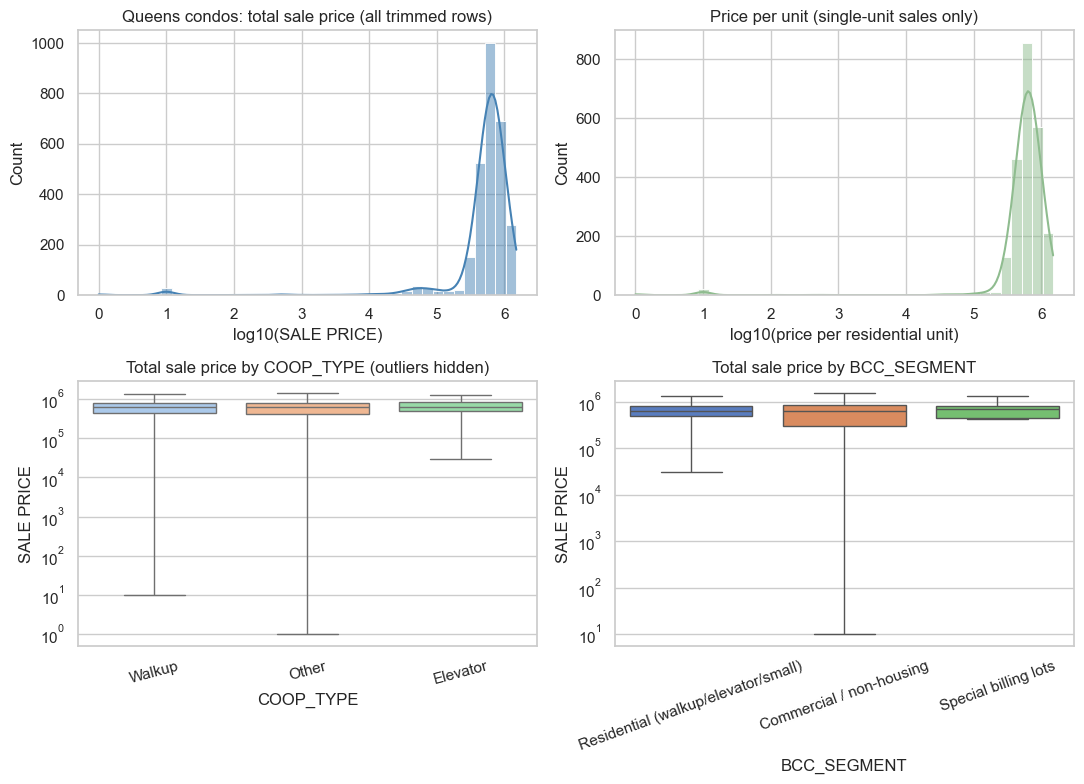

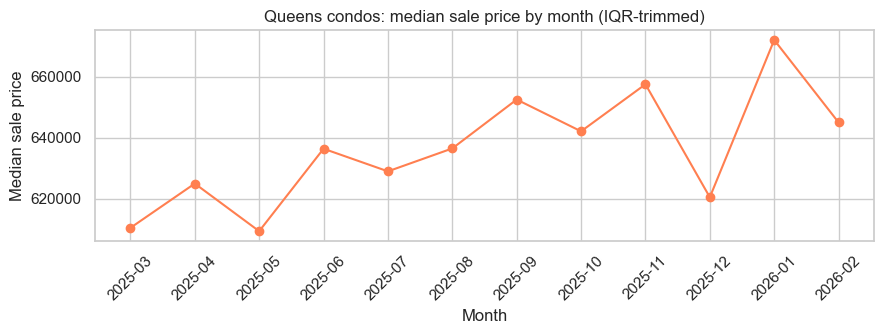

In [13]:
# Distributions: log scale for skewed prices; single-unit subset for $/unit
sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

ax = axes[0, 0]
sns.histplot(np.log10(coop_tp["SALE PRICE"]), bins=40, kde=True, ax=ax, color="steelblue")
ax.set_xlabel("log10(SALE PRICE)")
ax.set_title("Queens condos: total sale price (all trimmed rows)")

ax = axes[0, 1]
su = single["PRICE_PER_RES_UNIT"].dropna()
if len(su) > 0:
    sns.histplot(np.log10(su), bins=40, kde=True, ax=ax, color="darkseagreen")
    ax.set_xlabel("log10(price per residential unit)")
    ax.set_title("Price per unit (single-unit sales only)")
else:
    ax.set_title("No single-unit rows")

ax = axes[1, 0]
sns.boxplot(data=coop_tp, x="COOP_TYPE", y="SALE PRICE", showfliers=False, ax=ax, palette="pastel")
ax.set_yscale("log")
ax.set_title("Total sale price by COOP_TYPE (outliers hidden)")
ax.tick_params(axis="x", rotation=15)

ax = axes[1, 1]
sns.boxplot(data=coop_tp, x="BCC_SEGMENT", y="SALE PRICE", showfliers=False, ax=ax, palette="muted")
ax.set_yscale("log")
ax.set_title("Total sale price by BCC_SEGMENT")
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

monthly = (
    coop_tp.groupby("YEAR_MONTH", sort=True)["SALE PRICE"]
    .median()
    .reset_index(name="median_price")
)
monthly["YEAR_MONTH"] = monthly["YEAR_MONTH"].astype(str)

fig2, ax2 = plt.subplots(figsize=(9, 3.5))
ax2.plot(monthly["YEAR_MONTH"], monthly["median_price"], marker="o", color="coral")
ax2.set_ylabel("Median sale price")
ax2.set_xlabel("Month")
ax2.set_title("Queens condos: median sale price by month (IQR-trimmed)")
ax2.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


In [14]:
# Hedonic-style association: log(SALE PRICE) on single-unit sales only
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

reg_df = coop_tp[coop_tp["DEAL_SCOPE"] == "Single unit (likely apartment sale)"].copy()
reg_df = reg_df.dropna(subset=["SALE PRICE", "BUILDING_AGE"])
reg_df = reg_df[reg_df["BUILDING_AGE"] > 0]
reg_df["QUARTER_STR"] = reg_df["QUARTER"].astype(str)

y = np.log(reg_df["SALE PRICE"].to_numpy())
cat_cols = ["COOP_TYPE", "BCC_SEGMENT", "QUARTER_STR"]
num_cols = ["BUILDING_AGE"]

pre = ColumnTransformer(
    [
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)
pipe = Pipeline([("prep", pre), ("ols", LinearRegression())])
pipe.fit(reg_df[cat_cols + num_cols], y)
r2 = pipe.score(reg_df[cat_cols + num_cols], y)

feat_names = pipe.named_steps["prep"].get_feature_names_out()
coefs = pipe.named_steps["ols"].coef_
intercept = pipe.named_steps["ols"].intercept_

print(f"Single-unit rows in regression: {len(reg_df):,}")
print(f"R² (log price): {r2:.3f}")
print(f"Intercept: {intercept:.4f}")
print("\nCoefficients (log $ per unit change in covariate):")
for name, c in zip(feat_names, coefs):
    print(f"  {name}: {c:.5f}")


Single-unit rows in regression: 2,025
R² (log price): 0.026
Intercept: 13.3900

Coefficients (log $ per unit change in covariate):
  cat__COOP_TYPE_Other: 0.09389
  cat__COOP_TYPE_Walkup: 0.09434
  cat__BCC_SEGMENT_Special billing lots: 0.11434
  cat__QUARTER_STR_2025Q2: -0.14004
  cat__QUARTER_STR_2025Q3: 0.06682
  cat__QUARTER_STR_2025Q4: 0.01320
  cat__QUARTER_STR_2026Q1: 0.11080
  num__BUILDING_AGE: -0.00727
